# `epilink`: Integrating Evolutionary and Epidemiological Signals to Uncover Superspreading Dynamics

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from scripts.utils import *
from pathlib import Path

set_seaborn_paper_context(font_scale=1.5)

In [2]:
figs_dir = Path("../figures/main")
tabs_dir = Path("../tables")
ensure_dirs(figs_dir, sup_figs_dir, tabs_dir)

def read_table(path: str) -> pd.DataFrame:
    path = tabs_dir / f"{path}.parquet"
    return pd.read_parquet(path)

## Features of `epilink`

In [6]:
toit_df = read_table("characterise_epilink/characteristic_toit_grid")
toit_df = toit_df[toit_df["days"] <= 15]
tost_df = read_table("characterise_epilink/characteristic_tost_grid")
tost_df = tost_df[tost_df["days"].between(-10, 10)]
presymptomatic_fraction_df = read_table("characterise_epilink/characteristic_presymptomatic_fraction")
stage_df = read_table("characterise_epilink/characteristic_stage_samples")
clock_rates_df = read_table("characterise_epilink/characteristic_clock_rate_samples")
temporal_df = read_table("characterise_epilink/characteristic_temporal_linkage")
temporal_df = temporal_df.loc[temporal_df["days"] >= 0]
genetic_df = read_table("characterise_epilink/characteristic_genetic_linkage")
surface_df = read_table("characterise_epilink/characteristic_probability_surface")
surface_pivot = surface_df.pivot(index="days", columns="snp", values="probability")
scenarios_df = read_table("characterise_epilink/characteristic_genetic_scenarios")
scenario_pivot = scenarios_df.pivot(index="m", columns="snp", values="normalized")

In [ ]:
presymptomatic_fraction = presymptomatic_fraction_df.iloc[0, 0]
K = stage_df.loc[stage_df["stage"] == "latent", "value"].to_numpy()
P = stage_df.loc[stage_df["stage"] == "presymptomatic", "value"].to_numpy()
I = stage_df.loc[stage_df["stage"] == "symptomatic", "value"].to_numpy()

KP = K + P
KPI = KP + I

disease_dynamic = pd.DataFrame({
    "Latent": K,
    "Presymptomatic": KP,
    "Symptomatic": KPI,
}).melt(var_name="Stage", value_name="Duration")
disease_dynamic = disease_dynamic[disease_dynamic["Duration"] <= 15]

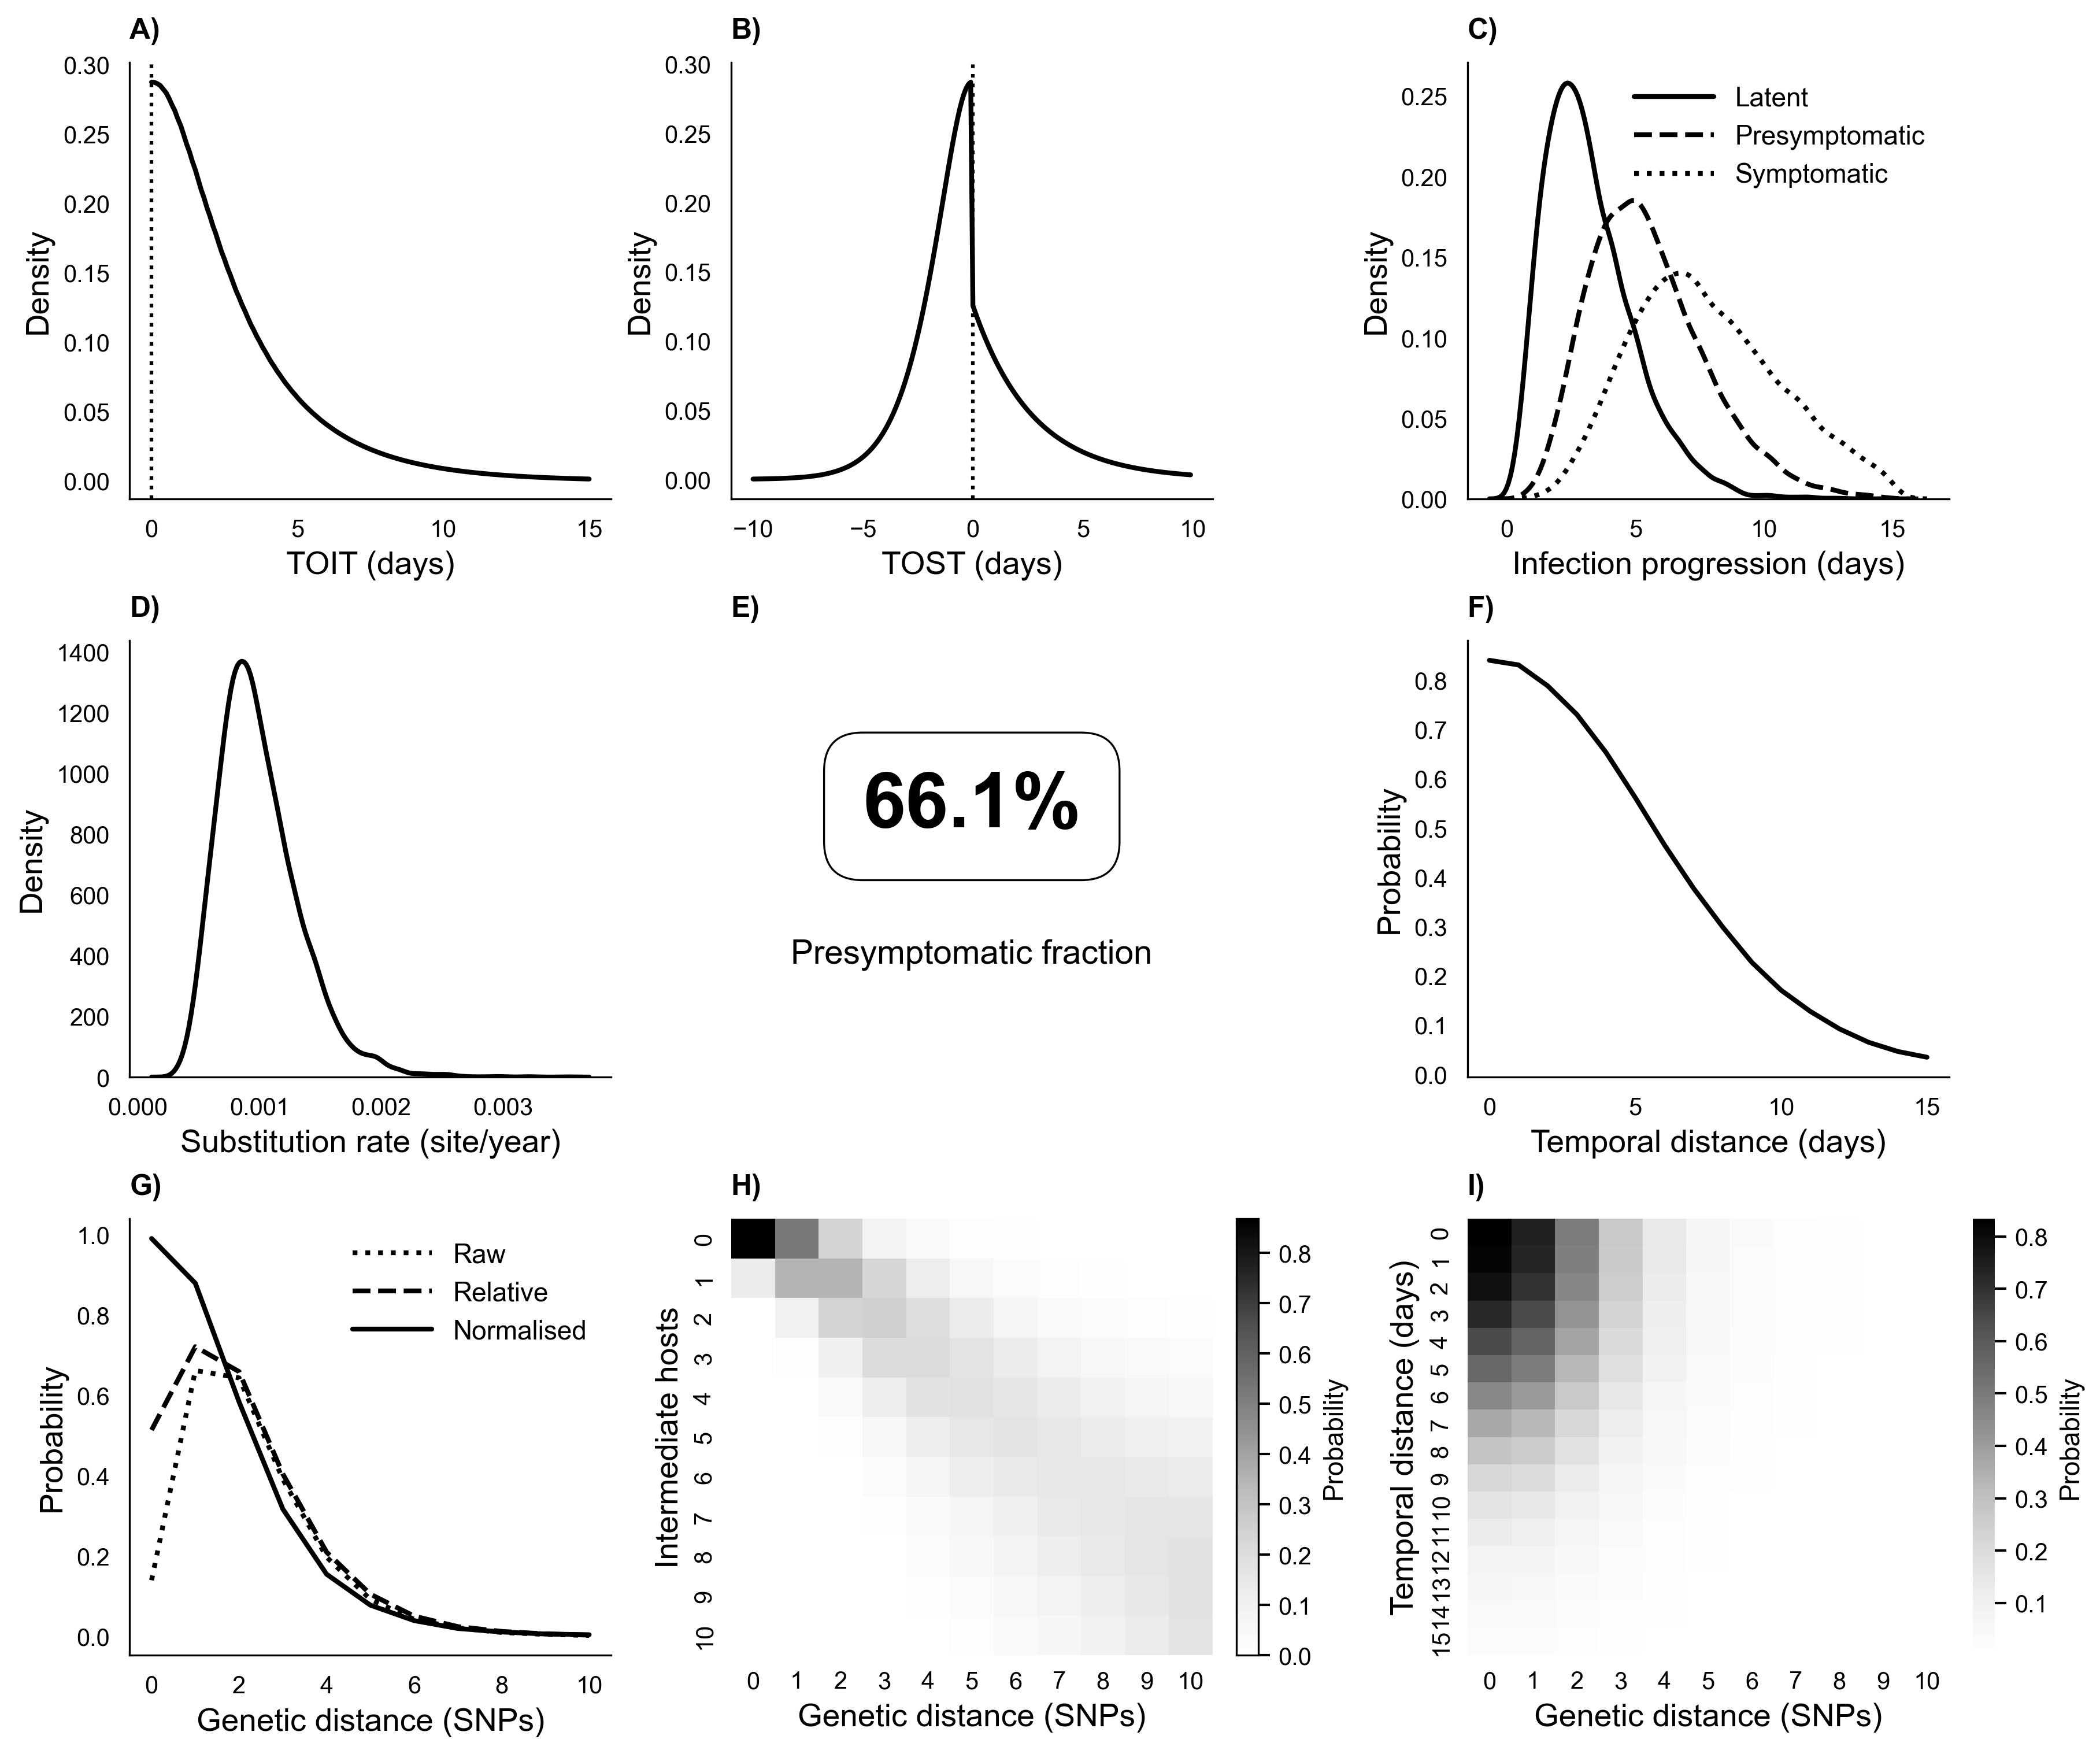

In [24]:
# -------------------------
# Figure + layout
# -------------------------
fig = plt.figure(figsize=(12, 10), constrained_layout=True)
gs = fig.add_gridspec(3, 3)

ax1 = fig.add_subplot(gs[0, 0])  # TOIT
ax2 = fig.add_subplot(gs[0, 1])  # TOST
ax3 = fig.add_subplot(gs[0, 2])  # Stage durations
ax4 = fig.add_subplot(gs[1, 0])  # Clock rate
ax5 = fig.add_subplot(gs[1, 1])  # Presymptomatic fraction
ax6 = fig.add_subplot(gs[1, 2])  # Temporal probability
ax7 = fig.add_subplot(gs[2, 0])  # Genetic curves
ax8 = fig.add_subplot(gs[2, 1])  # Scenario heatmap
ax9 = fig.add_subplot(gs[2, 2])  # Surface heatmap

font_size = "large"

# -------------------------
# A) TOIT
# -------------------------
sns.lineplot(data=toit_df, x="days", y="pdf", ax=ax1, color="black", lw=2)
ax1.axvline(0, color="black", linestyle=":", lw=1.5)
ax1.set_xlabel("TOIT (days)", fontsize=font_size)
ax1.set_ylabel("Density", fontsize=font_size)

# -------------------------
# B) TOST
# -------------------------
sns.lineplot(data=tost_df, x="days", y="pdf", ax=ax2, color="black", lw=2)
ax2.axvline(0, color="black", linestyle=":", lw=1.5)
ax2.set_xlabel("TOST (days)", fontsize=font_size)
ax2.set_ylabel("Density", fontsize=font_size)

# -------------------------
# C) Stage durations (lines + linestyles; no fill)
# -------------------------
# Stable ordering for reproducibility
stages = list(disease_dynamic["Stage"].dropna().unique())
linestyles = ["-", "--", ":", "-."]  # extend if you have >3 stages

for i, stage in enumerate(stages):
    sns.kdeplot(
        data=disease_dynamic[disease_dynamic["Stage"] == stage],
        x="Duration",
        ax=ax3,
        color="black",
        lw=2,
        linestyle=linestyles[i % len(linestyles)],
        fill=False,
        common_norm=False,
        label=str(stage),
    )

ax3.set_xlabel("Infection progression (days)", fontsize=font_size)
ax3.set_ylabel("Density", fontsize=font_size)

# Keep legend tidy
leg3 = ax3.legend(title=None, frameon=False, loc="best", handlelength=3,  fontsize="medium")
for line in leg3.get_lines():
    line.set_linewidth(2)

# -------------------------
# D) Clock rate distribution (no fill)
# -------------------------
sns.kdeplot(
    data=clock_rates_df,
    x="rate_per_site_year",
    ax=ax4,
    color="black",
    lw=2,
    fill=False
)
ax4.set_xlabel("Substitution rate (site/year)", fontsize=font_size)
ax4.set_ylabel("Density", fontsize=font_size)

# -------------------------
# E) Presymptomatic fraction “card”
# -------------------------
ax5.axis("off")
bbox = dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="black", linewidth=0.8)

ax5.text(
    0.5, 0.62, f"{presymptomatic_fraction:.1%}",
    ha="center", va="center",
    fontsize=32, weight="bold", color="black",
    bbox=bbox
)
ax5.text(
    0.5, 0.28, "Presymptomatic fraction",
    ha="center", va="center",
    fontsize=14, color="black"
)

# -------------------------
# F) Temporal component
# -------------------------
sns.lineplot(
    data=temporal_df,
    x="days",
    y="probability",
    ax=ax6,
    color="black",
    lw=2
)
ax6.set_xlabel("Temporal distance (days)", fontsize=font_size)
ax6.set_ylabel("Probability", fontsize=font_size)

# -------------------------
# G) Genetic component (linestyles distinguish curves)
# -------------------------
sns.lineplot(data=genetic_df, x="snp", y="raw",
             ax=ax7, color="black", lw=2, linestyle=":", label="Raw")
sns.lineplot(data=genetic_df, x="snp", y="relative",
             ax=ax7, color="black", lw=2, linestyle="--", label="Relative")
sns.lineplot(data=genetic_df, x="snp", y="normalized",
             ax=ax7, color="black", lw=2, linestyle="-", label="Normalised")

ax7.set_xlabel("Genetic distance (SNPs)", fontsize=font_size)
ax7.set_ylabel("Probability", fontsize=font_size)

leg7 = ax7.legend(frameon=False, loc="best", handlelength=3,  fontsize="medium")
for line in leg7.get_lines():
    line.set_linewidth(2)

# -------------------------
# H) Scenario heatmap (Greys)
# -------------------------
hm8 = sns.heatmap(
    scenario_pivot,
    cmap="Greys",
    ax=ax8,
    cbar_kws={"label": "Probability"},
    linewidths=0.0
)
ax8.set_xlabel("Genetic distance (SNPs)", fontsize=font_size)
ax8.set_ylabel("Intermediate hosts", fontsize=font_size)
ax8.tick_params(direction="out", length=3, width=0.8)

cbar8 = hm8.collections[0].colorbar
cbar8.outline.set_edgecolor("black")
cbar8.outline.set_linewidth(0.8)
cbar8.ax.yaxis.label.set_size("medium")

# -------------------------
# H) Surface heatmap (Greys)
# -------------------------
hm9 = sns.heatmap(
    surface_pivot,
    cmap="Greys",
    ax=ax9,
    cbar_kws={"label": "Probability"},
    linewidths=0.0
)
ax9.set_xlabel("Genetic distance (SNPs)", fontsize=font_size)
ax9.set_ylabel("Temporal distance (days)", fontsize=font_size)
ax9.tick_params(direction="out", length=3, width=0.8)

# Make colourbar a bit cleaner
cbar9 = hm8.collections[0].colorbar
cbar9.outline.set_edgecolor("black")
cbar9.outline.set_linewidth(0.8)
cbar9.ax.yaxis.label.set_size("medium")

# -------------------------
# Panel labels (A–I), left aligned
# -------------------------
for ax, t in zip(
    [ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9],
    ["A", "B", "C", "D", "E", "F", "G", "H", "I"]
):
    ax.set_title(f"{t})", pad=10, loc="left", fontweight="bold")

# -------------------------
# Save + show
# -------------------------
save_figure(fig, figs_dir / "epilink_feature_summary", ["png", "pdf"])
plt.show()

## Pairwise Discrimination and Cluster Recovery

In [25]:
MODELS = {
    "LinearDistScore": "Lin–Score",
    "PoissonDistScore": "Pois–Score",
    "ProbLinearDist": "Lin–Prob",
    "ProbPoissonDist": "Pois–Prob",
    "LogitLinearDist10": "Lin–Logit(10)",
    "LogitLinearDist100": "Lin–Logit(100)",
    "LogitPoissonDist10": "Pois–Logit(10)",
    "LogitPoissonDist100": "Pois–Logit(100)",
}

SCENARIOS = {
    "baseline": "Baseline",
    "surveillance_moderate": "Surveillance (moderate)",
    "surveillance_severe": "Surveillance (severe)",
    "low_clock_signal": "Low clock signal",
    "low_incubation_shape": "Low incubation shape",
    "low_incubation_scale": "Low incubation scale",
    "high_clock_signal": "High clock signal",
    "high_incubation_shape": "High incubation shape",
    "high_incubation_scale": "High incubation scale",
    "relaxed_clock": "Relaxed clock",
    "adversarial": "Adversarial",
}

In [27]:
discrimination = pd.read_parquet(tabs_dir / "discrimination/discrimination_metrics.parquet")
clustering_metrics = pd.read_parquet(tabs_dir / "clustering/clustering_metrics.parquet")
clustering_stability = pd.read_parquet(tabs_dir / "clustering/clustering_stability.parquet")
data_accrual = pd.read_parquet(tabs_dir / "temporal_stability/case_counts_over_time.parquet")
temporal_stability_ll = pd.read_parquet(tabs_dir / "temporal_stability/temporal_stability_logit_linear.parquet")
temporal_stability_lp = pd.read_parquet(tabs_dir / "temporal_stability/temporal_stability_logit_poisson.parquet")
temporal_stability_pl = pd.read_parquet(tabs_dir / "temporal_stability/temporal_stability_prob_linear.parquet")
temporal_stability_pp = pd.read_parquet(tabs_dir / "temporal_stability/temporal_stability_prob_poisson.parquet")

In [37]:
discrimination["ModelLabel"] = discrimination["Model"].map(MODELS)
discrimination["ScenarioLabel"] = discrimination["Scenario"].map(SCENARIOS)

clustering_metrics["ModelLabel"] = clustering_metrics["Weight_Column"].map(MODELS)
clustering_metrics["ScenarioLabel"] = clustering_metrics["Scenario"].map(SCENARIOS)

clustering_stability["ModelLabel"] = clustering_stability["Weight_Column"].map(MODELS)
clustering_stability["ScenarioLabel"] = clustering_stability["Scenario"].map(SCENARIOS)

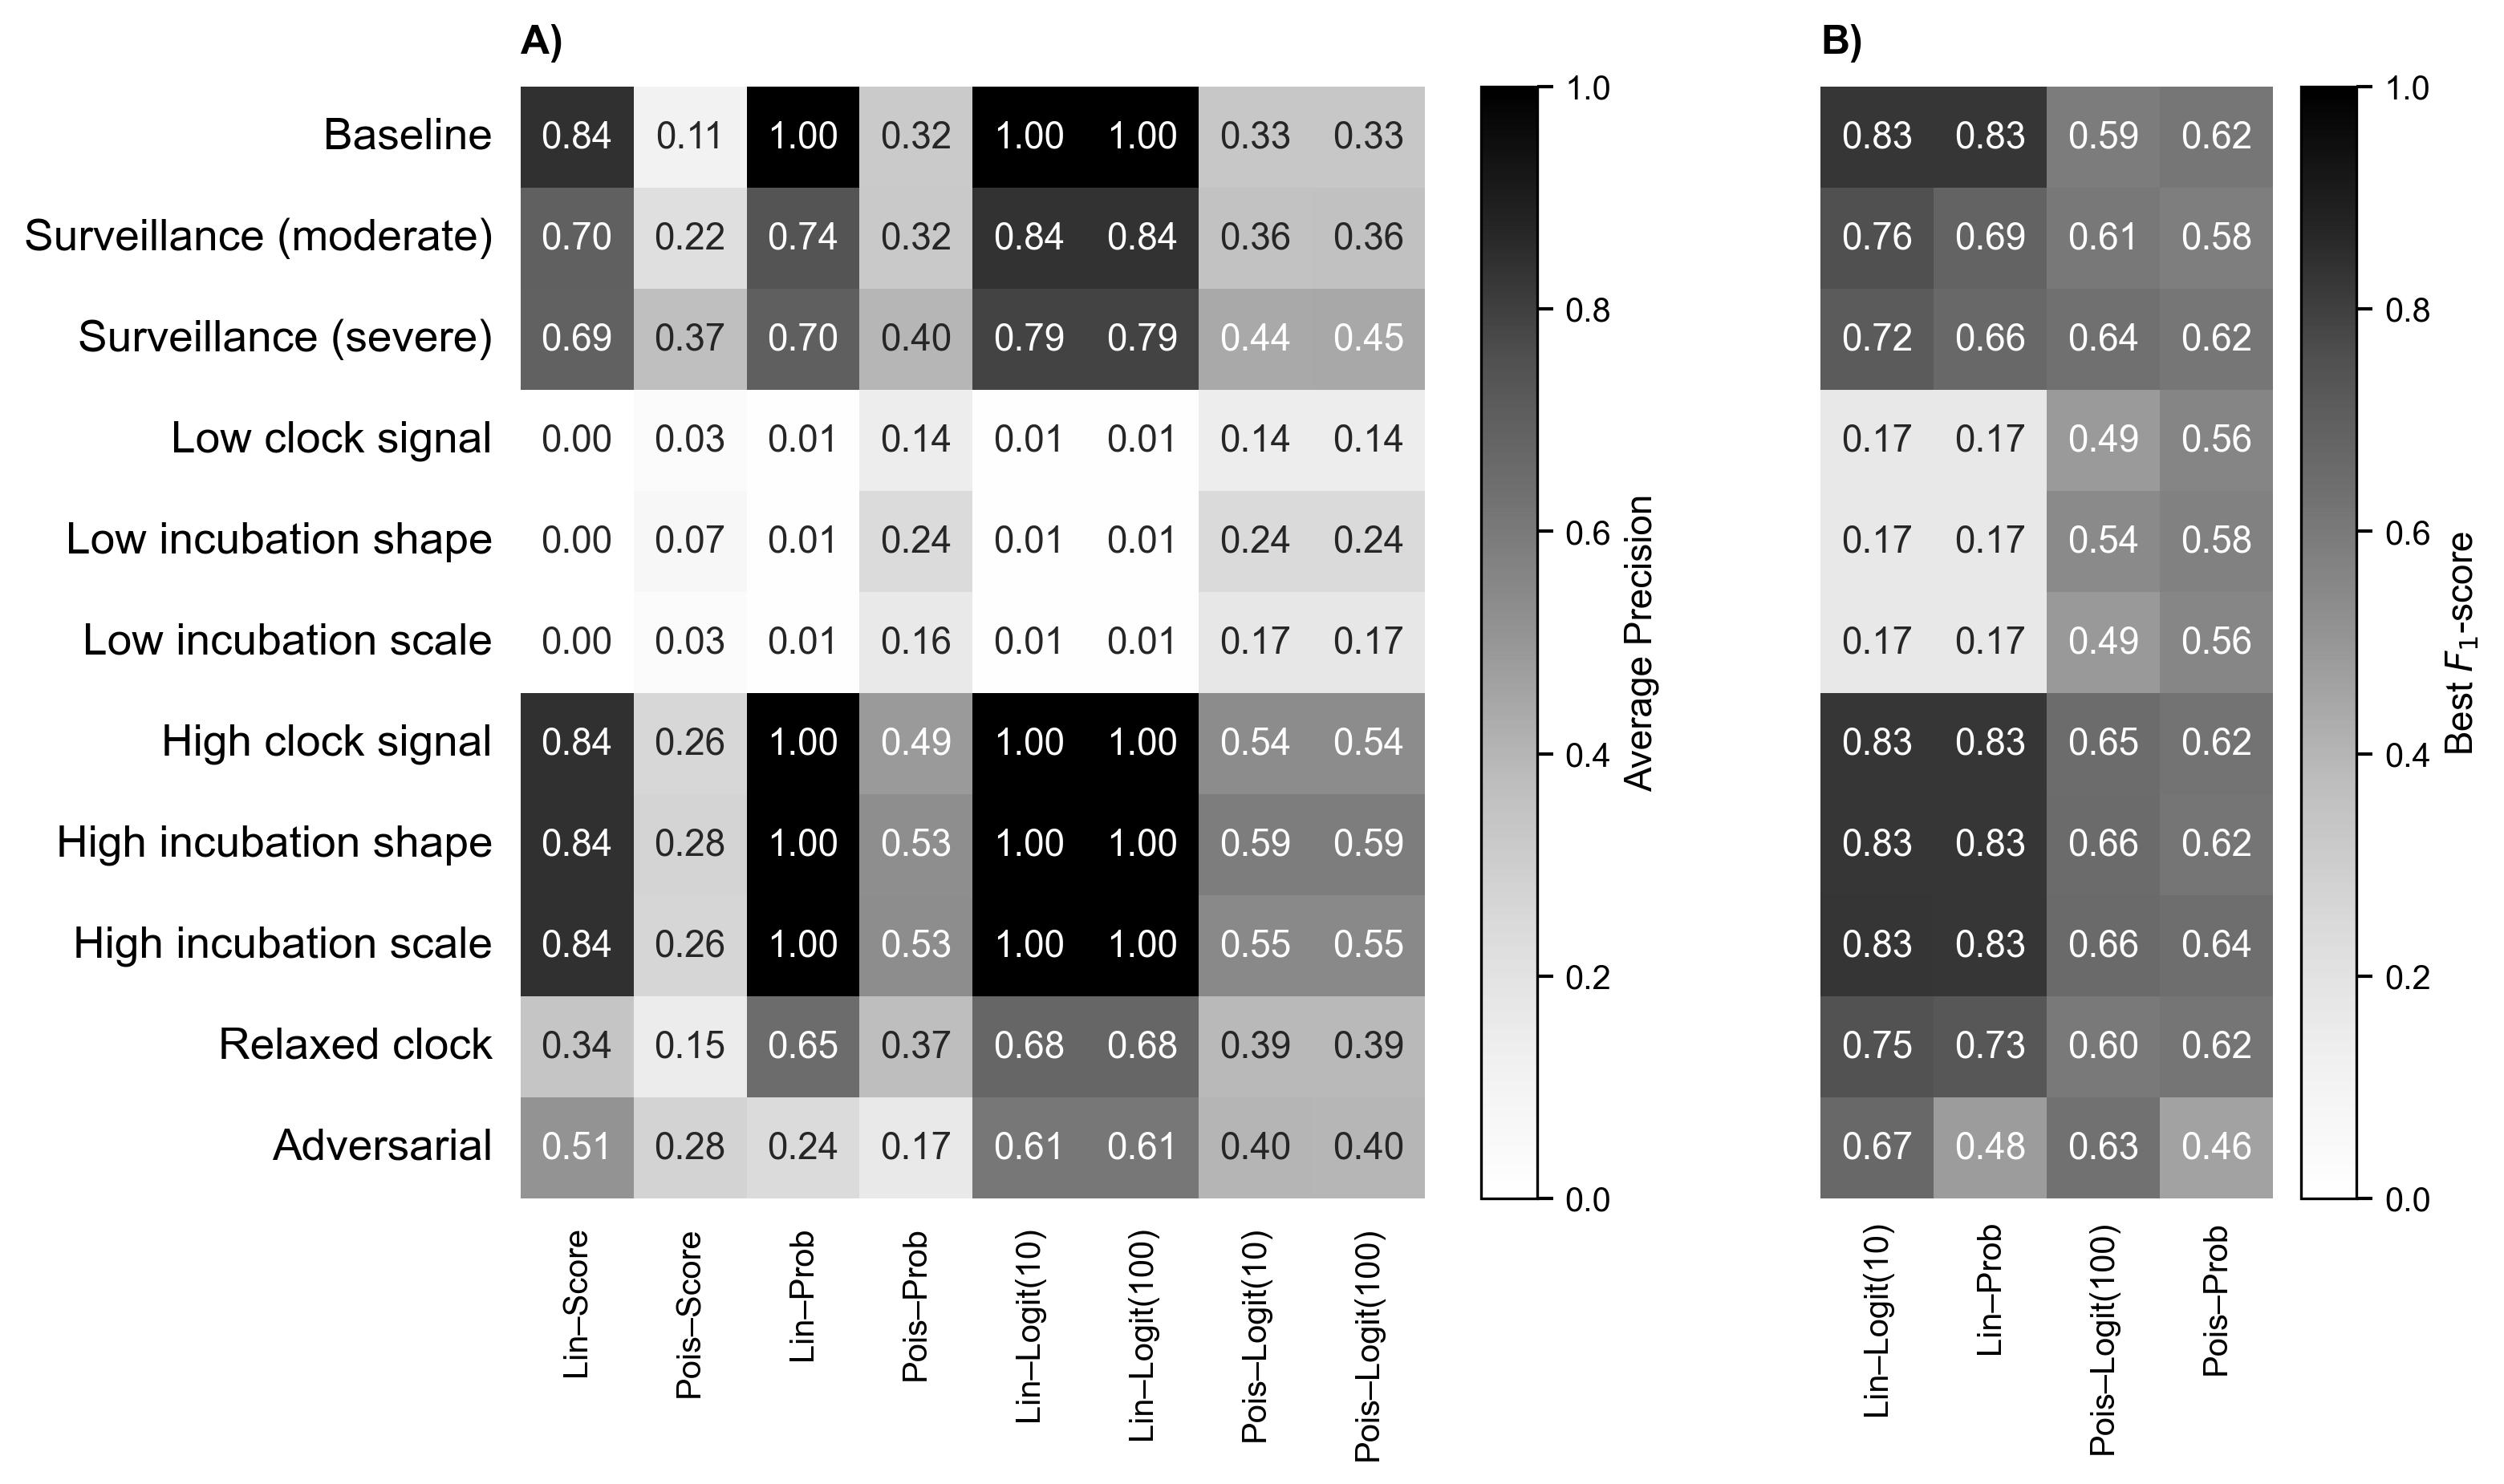

In [67]:
model_order = list(MODELS.values())
scenario_order = list(SCENARIOS.values())

pr_heat = discrimination.pivot(
    index="ScenarioLabel",
    columns="ModelLabel",
    values="PR_AUC",
).reindex(index=scenario_order, columns=model_order)

best_f1 = clustering_metrics.groupby(
    ["ScenarioLabel", "ModelLabel"], as_index=False
)["BCubed_F1_Score"].max()


best_f1_heat = best_f1.pivot(
    index="ScenarioLabel",
    columns="ModelLabel",
    values="BCubed_F1_Score",
).reindex(index=scenario_order)

fig, axes = plt.subplots(1, 2, figsize=(10, 6), sharey=True,
                         width_ratios=[2, 1])
hm0 = sns.heatmap(
    pr_heat,
    vmin=0, vmax=1,
    cmap="Greys",
    annot=True, fmt=".2f",
    cbar_kws={"label": "Average Precision"},
    ax=axes[0]
)
axes[0].set_xlabel("")
axes[0].set_ylabel("")
axes[0].tick_params(axis='y', labelsize="large")
axes[0].set_title("A)", pad=10, loc="left", fontweight="bold")
# axes[0].tick_params(direction="out", length=3, width=0.8)

cbar0 = hm0.collections[0].colorbar
cbar0.outline.set_edgecolor("black")
cbar0.outline.set_linewidth(0.8)
cbar0.ax.yaxis.label.set_size("medium")

hm1 = sns.heatmap(
    best_f1_heat,
    vmin=0, vmax=1,
    cmap="Greys",
    annot=True, fmt=".2f",
    cbar_kws={"label": r"Best $F_1$-score"},
    ax=axes[1]
)
axes[1].set_xlabel("")
axes[1].set_ylabel("")
axes[1].set_title("B)", pad=10, loc="left", fontweight="bold")
axes[1].tick_params(direction="out", length=3, width=0.8)

cbar1 = hm1.collections[0].colorbar
cbar1.outline.set_edgecolor("black")
cbar1.outline.set_linewidth(0.8)
cbar1.ax.yaxis.label.set_size("medium")

save_figure(fig, figs_dir / "discrimination_recovery", ["png", "pdf"])
plt.show()

### Supplementary figures and tables

In [71]:
import string
def plot_cluster_metrics(df, out_path, metric="BCubed_F1_Score", col_wrap=3):
    m_order = ['Lin–Prob', 'Lin–Logit(100)', 'Pois–Prob', 'Pois–Logit(100)']

    # line styles + markers to replace colours
    linestyles = {
        'Lin–Prob': '-',
        'Lin–Logit(100)': '--',
        'Pois–Prob': ':',
        'Pois–Logit(100)': '-.'
    }

    markers = {
        'Lin–Prob': 'o',
        'Lin–Logit(100)': 's',
        'Pois–Prob': '^',
        'Pois–Logit(100)': 'D'
    }

    g = sns.relplot(
        data=df,
        x="Resolution",
        y=metric,
        hue="ModelLabel",
        hue_order=m_order,
        style="ModelLabel",
        style_order=m_order,
        markers=markers,
        dashes=linestyles,
        palette=["black"] * len(m_order),   # force monochrome
        col="ScenarioLabel",
        col_order=scenario_order,
        col_wrap=col_wrap,
        kind="line",
        height=2.8,
        aspect=1.15,
        linewidth=2,
    )

    # axis labels
    g.set_axis_labels(r"Resolution ($\gamma$)", "-".join(metric.split("_")[1:]))
    g.set(ylim=(0, 1.05))

    # clean axes style
    for ax in g.axes.flatten():
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.grid(True, axis="y", alpha=0.25)
        ax.grid(False, axis="x")

    # Panel titles
    g.set_titles("{col_name}", loc="left", fontweight="bold")

    # Add A, B, C ... panel labels
    for ax, label in zip(g.axes.flatten(), string.ascii_uppercase):
        ax.text(
            -0.15,
            1.08,
            f"{label})",
            transform=ax.transAxes,
            fontsize=11,
            fontweight="bold",
            va="top",
        )

    # legend
    g.legend.set_title("Probability and Genome Simulation Model")

    sns.move_legend(
        g,
        loc="upper center",
        bbox_to_anchor=(0.45, 1.10),
        ncol=4,
        frameon=False,
    )

    # save
    g.figure.savefig(out_path.with_suffix(".png"), dpi=300, bbox_inches="tight")
    g.figure.savefig(out_path.with_suffix(".pdf"), bbox_inches="tight")

    plt.show()
    plt.close(g.figure)

TypeError: unsupported operand type(s) for +: 'int' and 'str'

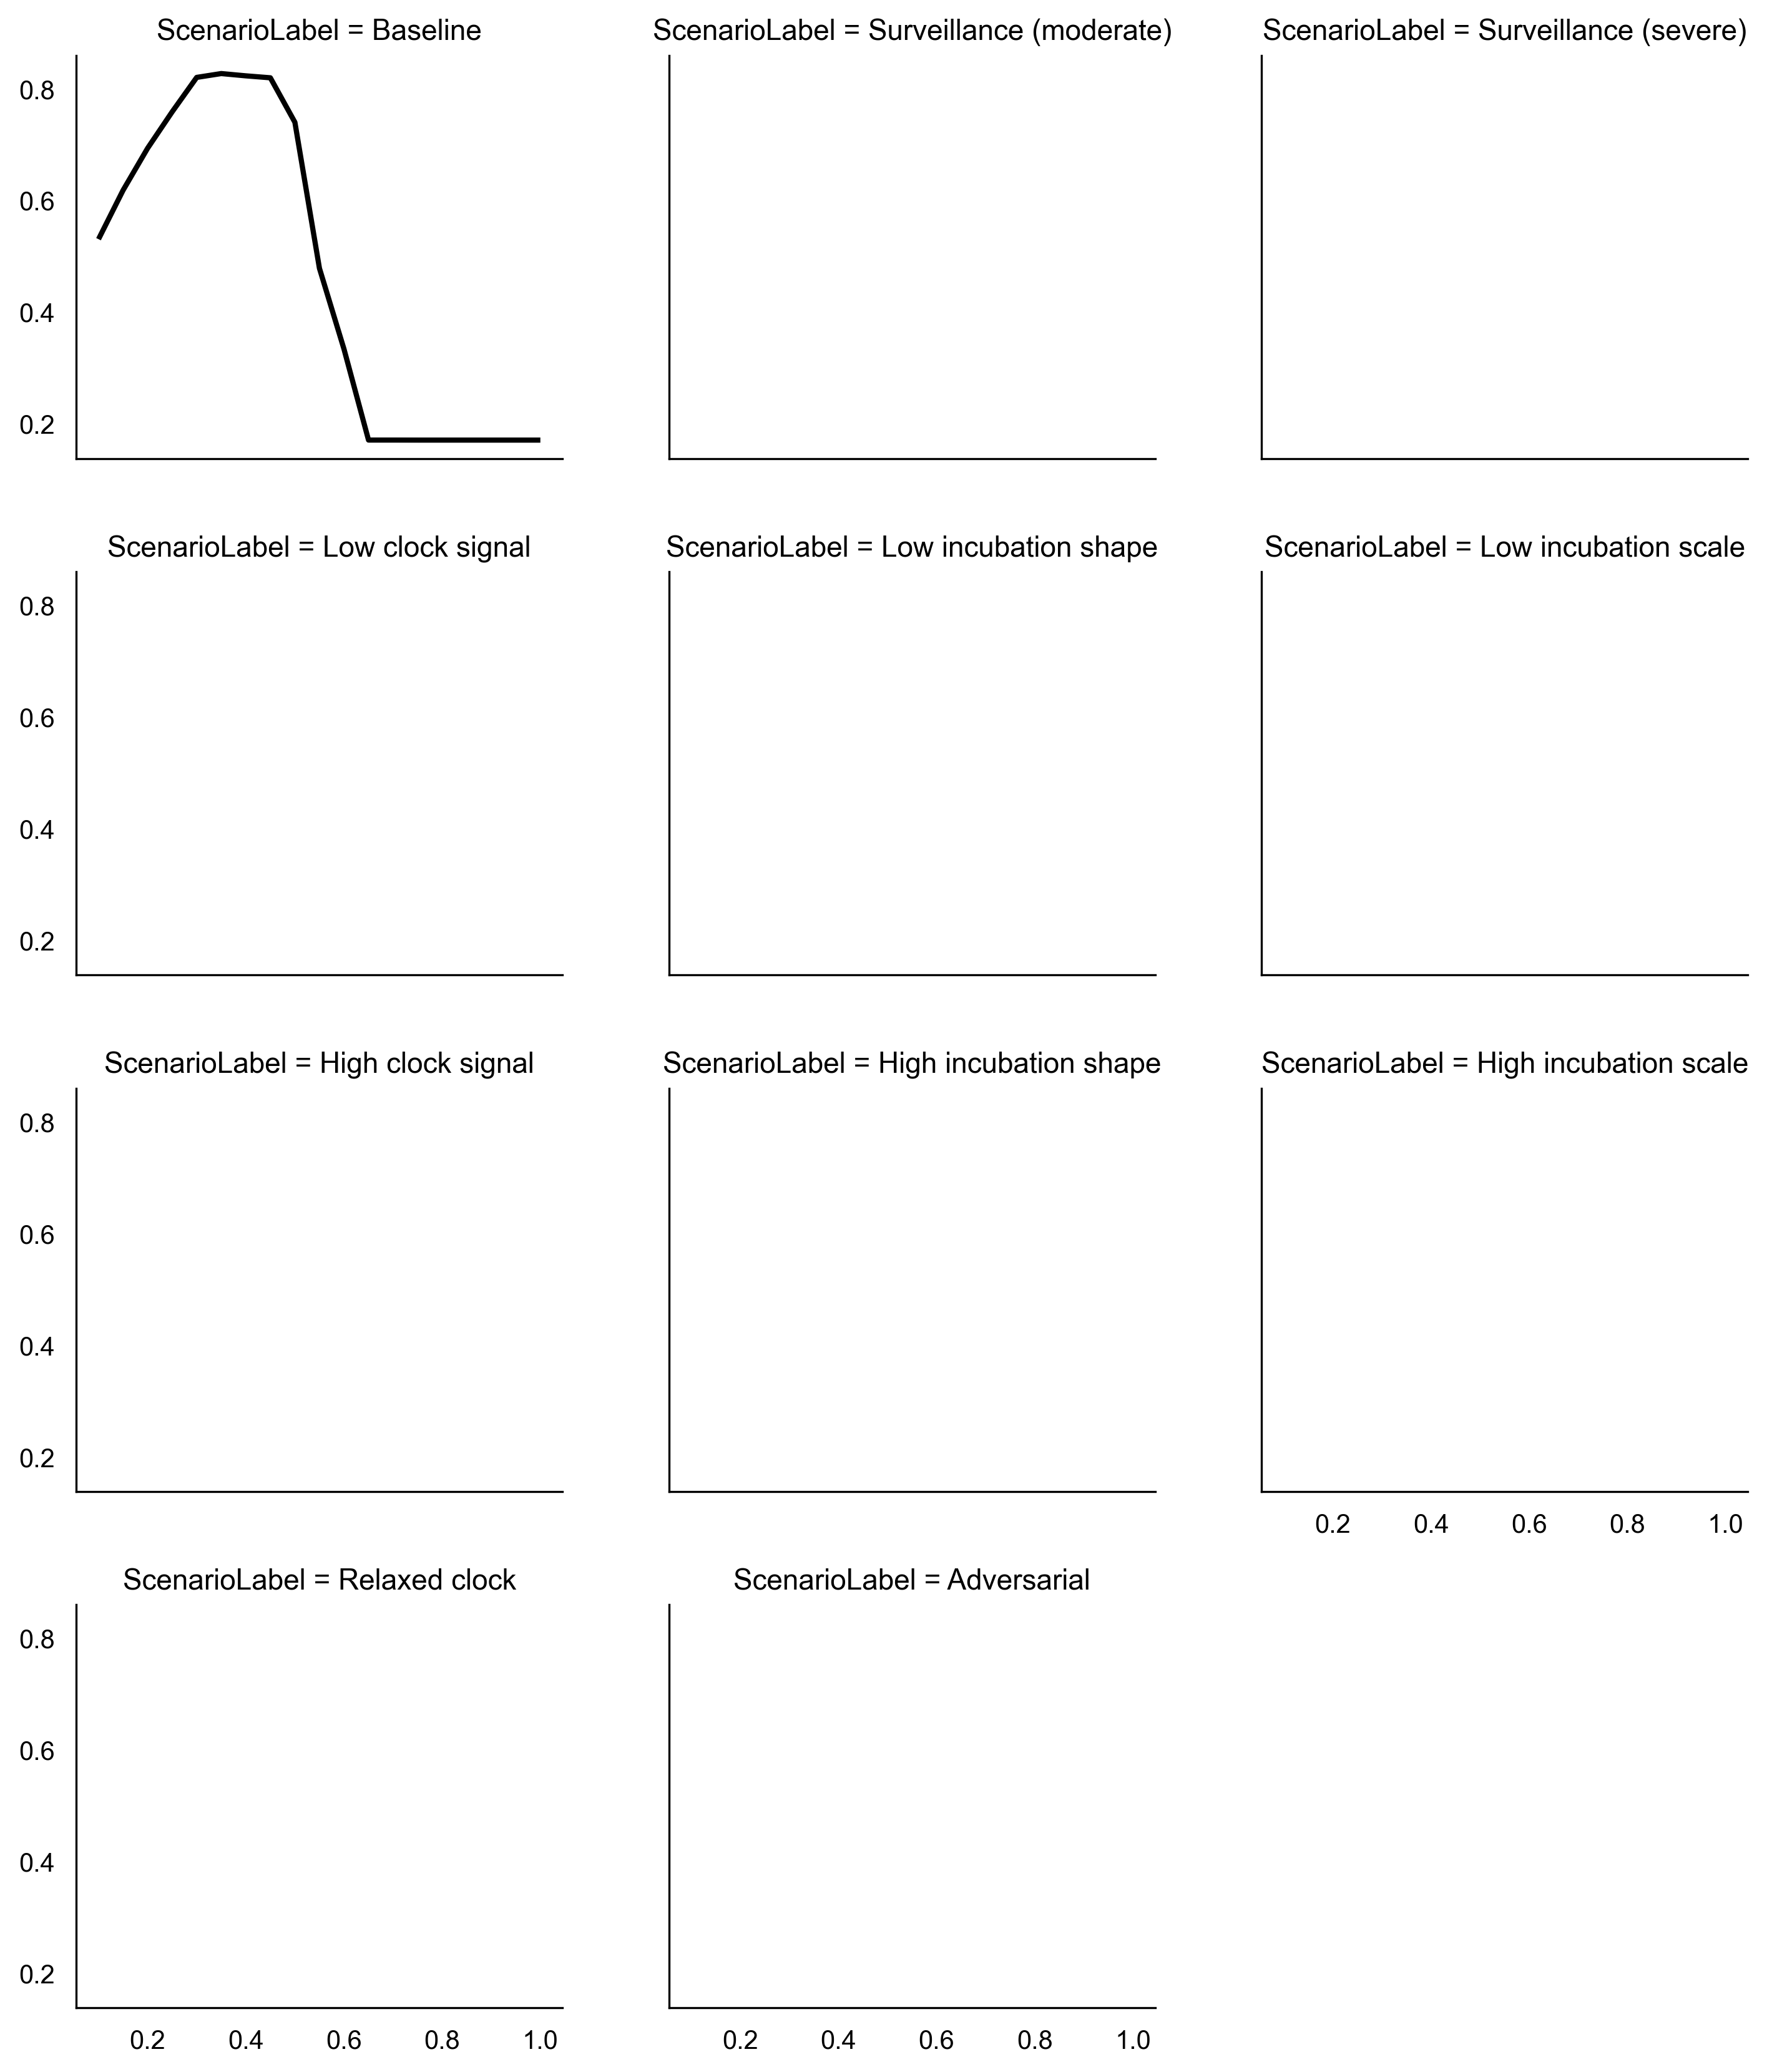

In [72]:
plot_cluster_metrics(
    clustering_metrics,
    figs_dir / "sm_cluster_metrics_f1",
    metric="BCubed_F1_Score",
    col_wrap=3
)

In [62]:
def plot_cluster_metrics(df, out_path, metric="BCubed_F1_Score", col_wrap=3):
    m_order = ['Lin–Prob', 'Lin–Logit(100)', 'Pois–Prob', 'Pois–Logit(100)']
    g = sns.relplot(
        data=df,
        x="Resolution",
        y=metric,
        hue="ModelLabel",
        hue_order=m_order,
        col="ScenarioLabel",
        col_order=scenario_order,
        col_wrap=col_wrap,
        kind="line",
        marker="o",
        height=2.8,
        aspect=1.15,
    )

    g.set_titles("Scenario| {col_name}", loc="left", fontweight="bold")
    g.set_axis_labels(r"Resolution ($\gamma$)", "-".join(metric.split("_")[1:]))
    g.set(ylim=(0, 1.05))
    g.legend.set_title("Probability and Genome Simulation Model")
    sns.move_legend(
        g,
        loc="upper center",
        bbox_to_anchor=(0.45, 1.08),
        ncol=4,
        frameon=True,
    )
    g.figure.savefig(out_path.with_suffix(".png"), dpi=300, bbox_inches="tight")
    g.figure.savefig(out_path.with_suffix(".pdf"), bbox_inches="tight")

    plt.show()
    plt.close(g.figure)

def plot_stability_metrics(df, out_path, metric="BCubed_F1_Score", col_wrap=3):
    m_order = ['Lin–Prob', 'Lin–Logit(1.0)', 'Pois–Prob', 'Pois–Logit(1.0)']
    g = sns.relplot(
        data=df,
        x="res1",
        y=metric,
        hue="ModelLabel",
        hue_order=m_order,
        col="ScenarioLabel",
        col_order=scenario_order,
        col_wrap=col_wrap,
        kind="line",
        marker="o",
        height=2.8,
        aspect=1.15,
    )

    g.set_titles("{col_name}")
    g.set_axis_labels(r"Resolution ($\gamma$)", "-".join(metric.split("_")[1:]))
    g.set(ylim=(0, 1.05))
    g.legend.set_title("Genome Divergence and Weighting Model")
    sns.move_legend(
        g,
        loc="upper center",
        bbox_to_anchor=(0.45, 1.08),
        ncol=4,
        frameon=True,
    )

    g.figure.savefig(out_path.with_suffix(".png"), dpi=300, bbox_inches="tight")
    g.figure.savefig(out_path.with_suffix(".pdf"), bbox_inches="tight")
    plt.show()
    plt.close(g.figure)

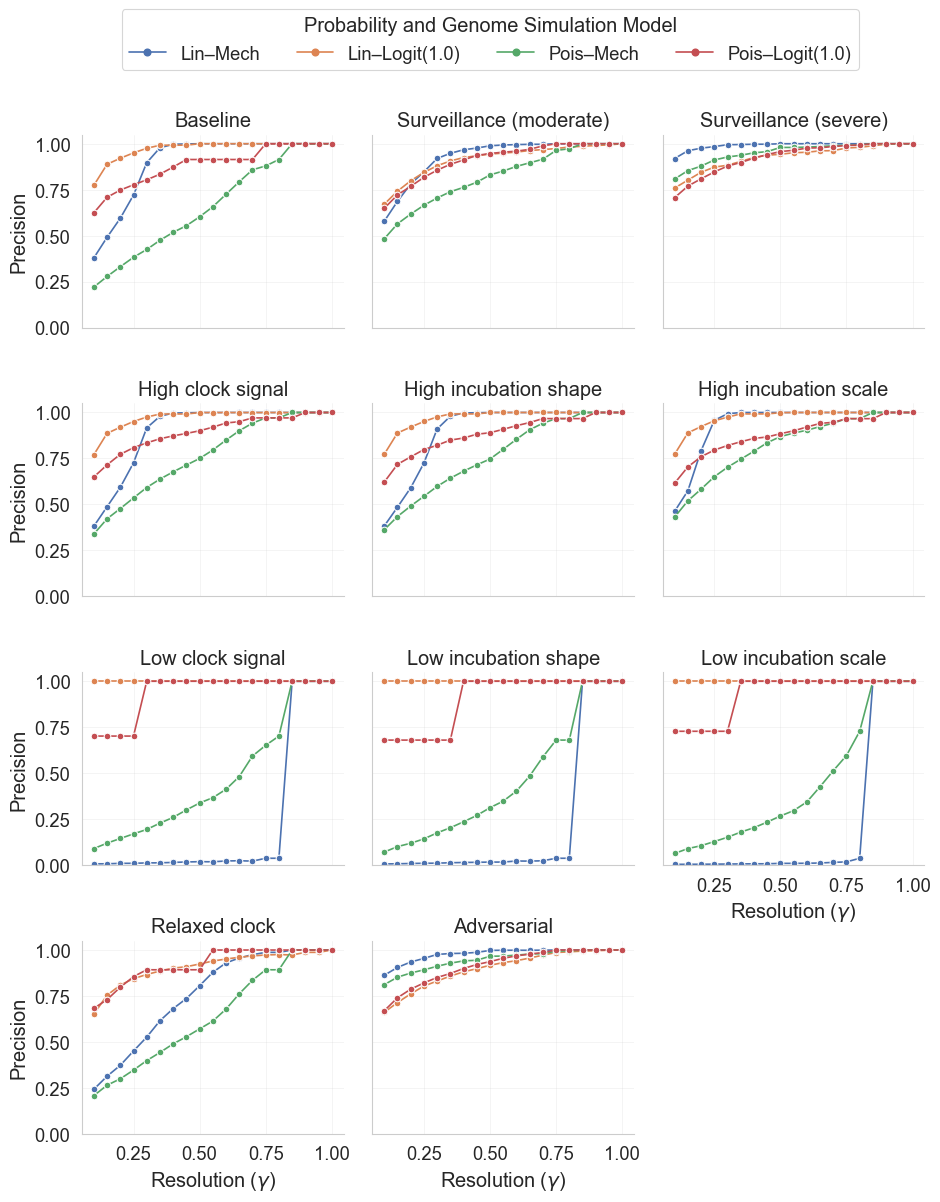

In [61]:
plot_cluster_metrics(
    clustering_metrics,
    sup_figs_dir / "sm6_cluster_metrics_precision",
    metric="BCubed_Precision",
    col_wrap=3
)

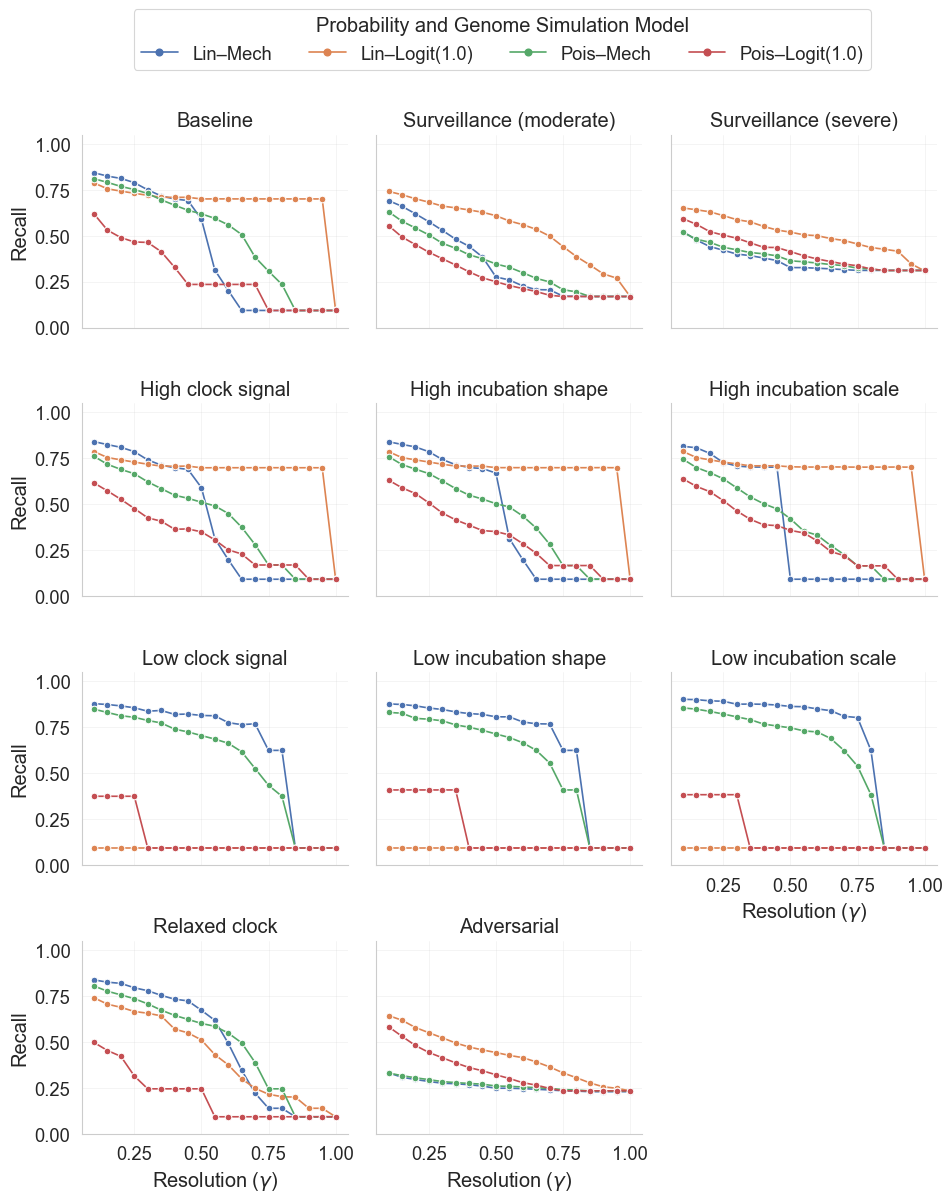

In [62]:
plot_cluster_metrics(
    clustering_metrics,
    sup_figs_dir / "sm6_cluster_metrics_recall",
    metric="BCubed_Recall",
    col_wrap=3
)

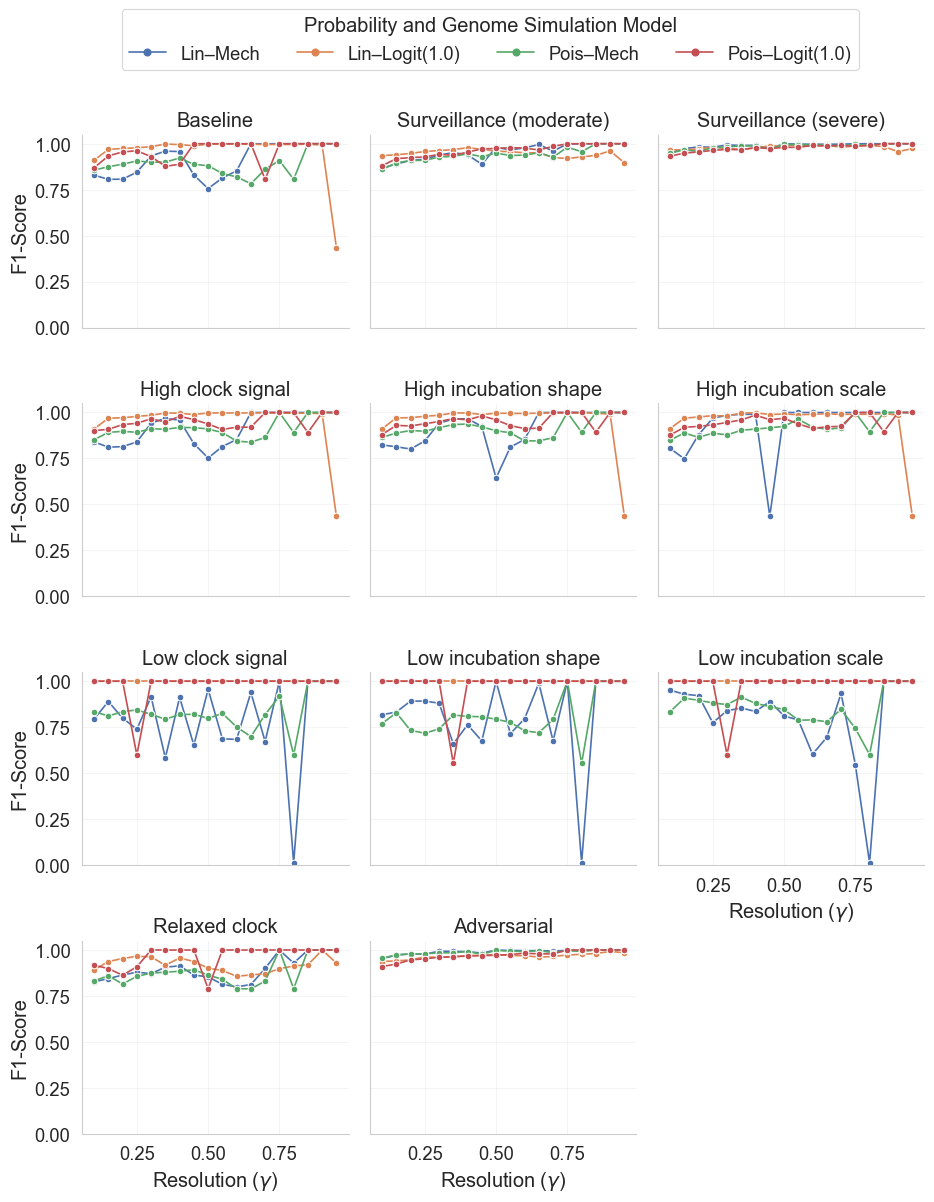

In [67]:
plot_stability_metrics(
    clustering_stability,
    sup_figs_dir / "sm6_clustering_stability_f1",
    metric="BCubed_F1_Score",
    col_wrap=3
)